Simple hierarchical 1PL-esque item-response-theory model.

See [Stan docs](https://mc-stan.org/docs/stan-users-guide/regression.html#item-response-models.section) for a nice description. For the sake of identifiability, this model assumes a fixed (non-hierarchical) prior over `theta`.

In [66]:
import pangolin
from pangolin import interface as pi
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [67]:
# params
num_students = 100
num_items    = 30
num_obs      = 10 * num_students

In [68]:
# random observation pattern
students = np.random.randint(0, num_students, num_obs) # which student in each observation
items    = np.random.randint(0, num_items, num_obs)    # which item in each observation

In [69]:
# model definition

# person ability
theta         = pi.vmap(pi.normal, None, num_students)(0.0, 1.0)

# item difficulty (non-centered)
mean_items    = pi.normal(0, 5)
std_items     = pi.exponential(1.0)
beta_raw      = pi.vmap(pi.normal, None, num_items)(0.0, 1.0)
beta          = mean_items + (beta_raw * std_items)

# likelihood
scores        = theta[students] - beta[items]
y             = pi.vmap(pi.bernoulli_logit)(scores)

In [70]:
# group latent variables for convenience
z = dict(theta=theta, beta=beta)

In [71]:
# generate synthetic data and secret true params
[y_obs, z_true] = pangolin.jax_backend.ancestor_sample([y, z])

In [72]:
# do inference
z_samps = pangolin.blackjax.sample(z, y, y_obs, niter=10000)

We now have a standard python dictionary of samples stored in normal numpy arrays.

In [73]:
# print shapes
for item in z_samps:
    print(item, z_samps[item].shape)

beta (10000, 30)
theta (10000, 100)


Everything below this is plotting code that doesn't use pangolin at all.

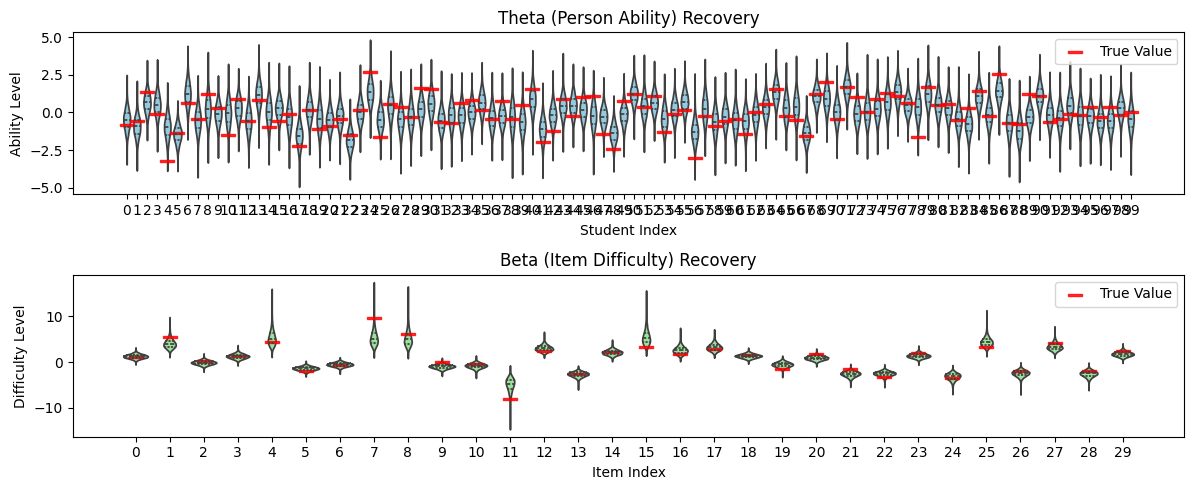

In [74]:
def plot_irt_recovery(z_samps, z_true):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5))

    # 1. Plot Theta (Person Ability)
    # Reshape to (num_samples, num_students)
    theta_samps = z_samps['theta'] 
    num_students = theta_samps.shape[1]

    sns.violinplot(data=theta_samps, ax=axes[0], color="skyblue", inner="quartile")
    axes[0].scatter(range(num_students), z_true['theta'], 
                   color='red', marker='$-$', s=100, label='True Value', alpha=0.8)
    axes[0].set_title("Theta (Person Ability) Recovery")
    axes[0].set_xlabel("Student Index")
    axes[0].set_ylabel("Ability Level")
    axes[0].legend()

    # 2. Plot Beta (Item Difficulty)
    # Reshape to (num_samples, num_items)
    beta_samps = z_samps['beta']
    num_items = beta_samps.shape[1]

    sns.violinplot(data=beta_samps, ax=axes[1], color="lightgreen", inner="quartile")
    axes[1].scatter(range(num_items), z_true['beta'], 
                   color='red', marker='$-$', s=100, label='True Value', alpha=0.8)
    axes[1].set_title("Beta (Item Difficulty) Recovery")
    axes[1].set_xlabel("Item Index")
    axes[1].set_ylabel("Difficulty Level")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Usage:
plot_irt_recovery(z_samps, z_true)

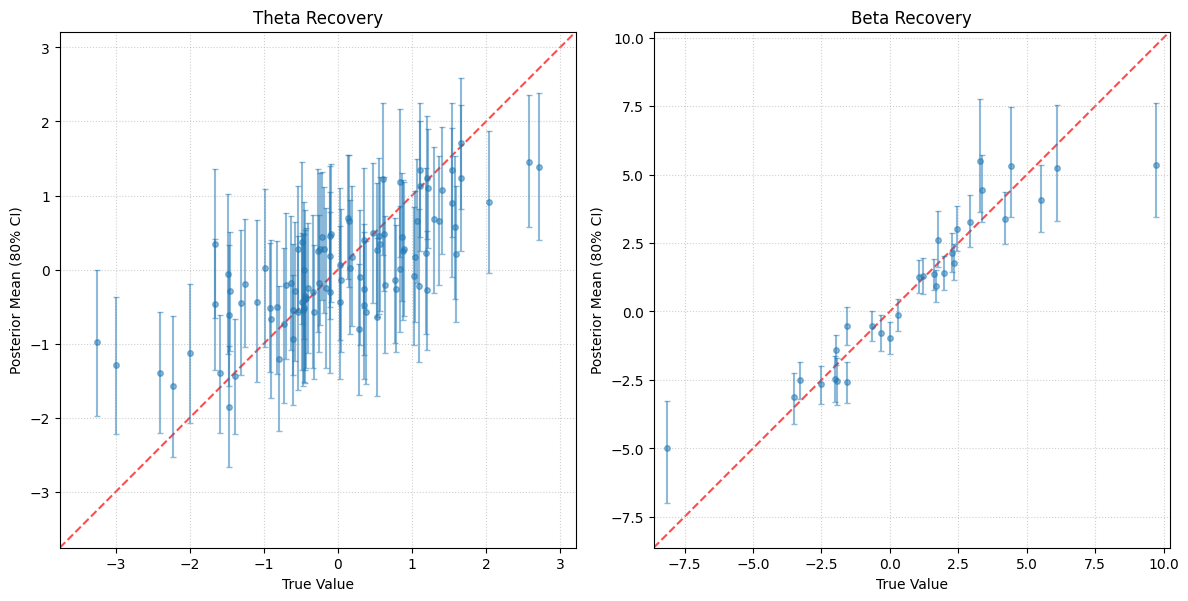

In [75]:
def plot_recovery_scatter(z_samps, z_true):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i, param in enumerate(['theta', 'beta']):
        # Calculate posterior mean and 80% Credible Interval
        post_mean = np.mean(z_samps[param], axis=0)
        lower = np.percentile(z_samps[param], 10, axis=0)
        upper = np.percentile(z_samps[param], 90, axis=0)
        true_val = z_true[param]

        # Scatter plot with error bars
        axes[i].errorbar(true_val, post_mean, 
                         yerr=[post_mean - lower, upper - post_mean],
                         fmt='o', alpha=0.5, capsize=2, markersize=4)

        # Calculate absolute limits to keep the plot square
        # We look at true values, means, and the CI bounds
        all_vals = np.concatenate([true_val, lower, upper])
        min_lim, max_lim = all_vals.min() - 0.5, all_vals.max() + 0.5

        # Apply limits to both axes
        axes[i].set_xlim(min_lim, max_lim)
        axes[i].set_ylim(min_lim, max_lim)

        # Force the plot to be physically square
        axes[i].set_aspect('equal', adjustable='box')

        # Identity line (Perfect recovery)
        axes[i].plot([min_lim, max_lim], [min_lim, max_lim], 
                     color='red', linestyle='--', alpha=0.7, zorder=0)

        axes[i].set_title(f"{param.capitalize()} Recovery")
        axes[i].set_xlabel("True Value")
        axes[i].set_ylabel("Posterior Mean (80% CI)")
        axes[i].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_recovery_scatter(z_samps, z_true)

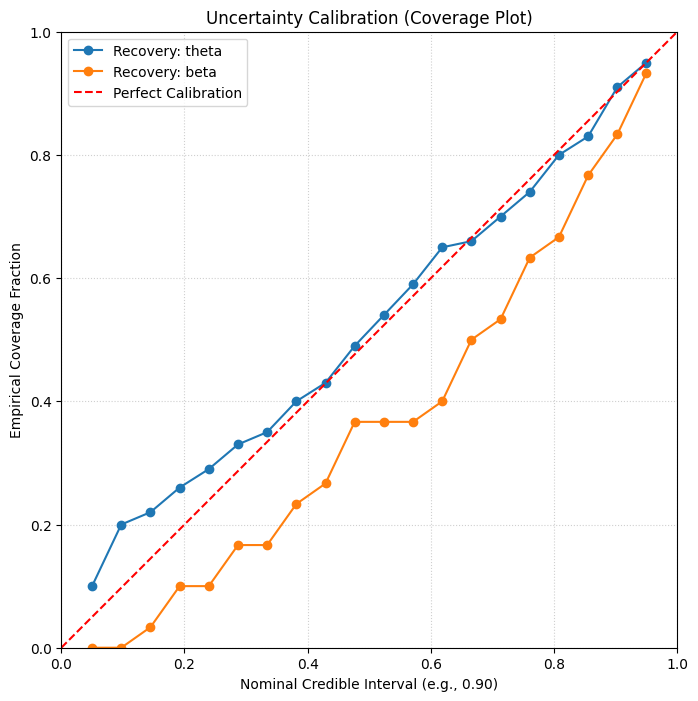

In [76]:
def plot_coverage_calibration(z_samps, z_true):
    # Define the range of credible intervals to check
    # e.g., 0.1 means the middle 10% of the posterior
    intervals = np.linspace(0.05, 0.95, 20)

    fig, ax = plt.subplots(figsize=(8, 8))

    for param in ['theta', 'beta']:
        samps = z_samps[param]  # Shape: (num_samples, num_elements)
        true_vals = z_true[param]
        coverage_fractions = []

        for ci in intervals:
            # Calculate lower and upper percentiles for the given CI
            lower_p = (1 - ci) / 2 * 100
            upper_p = (1 + ci) / 2 * 100

            lower_bound = np.percentile(samps, lower_p, axis=0)
            upper_bound = np.percentile(samps, upper_p, axis=0)

            # Check if true value is within the bounds
            is_inside = (true_vals >= lower_bound) & (true_vals <= upper_bound)
            coverage_fractions.append(np.mean(is_inside))

        ax.plot(intervals, coverage_fractions, marker='o', label=f'Recovery: {param}')

    # Identity line: Perfect calibration
    ax.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Calibration')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel("Nominal Credible Interval (e.g., 0.90)")
    ax.set_ylabel("Empirical Coverage Fraction")
    ax.set_title("Uncertainty Calibration (Coverage Plot)")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.show()

plot_coverage_calibration(z_samps, z_true)